<a href="https://colab.research.google.com/github/KarlaRL666/DataAnalysisPython/blob/main/HechosYDimensiones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Importamos las librerias necesarias
import sqlite3 # Para crear una base de datos en memoria
import pandas as pd # Para trabajar con datos
import matplotlib.pyplot as plt # Para generar graficas

In [ ]:
# 2. Creamos una conexion a una base de datos en memoria
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

In [ ]:
# 3. Creamos la tabla de hechos: reciclaje
cursor.execute("""
CREATE TABLE reciclaje(
id_registro INTEGER PRIMARY KEY,
id_tiempo INTEGER,
id_ciudad INTEGER,
id_material INTEGER,
cantidad INTEGER,
peso_kg REAL
)
""")

In [ ]:
# 4. Creamos la dimension ciudades
cursor.execute("""
CREATE TABLE ciudades(
id_ciudad INTEGER PRIMARY KEY,
nombre TEXT,
region TEXT
)
""")

In [ ]:
# 5. Creamos la dimension materiales
cursor.execute("""
CREATE TABLE materiales(
id_material INTEGER PRIMARY KEY,
tipo TEXT,
categoria TEXT
)
""")

In [ ]:
# 6. Creamos la dimension tiempo
cursor.execute("""
CREATE TABLE tiempo(
id_tiempo INTEGER PRIMARY KEY,
anio INTEGER,
mes INTEGER,
dia INTEGER
)
""")

In [ ]:
# 7. Insertamos datos en la dimension ciudades (3 ciudades diferentes)
cursor.executemany("INSERT INTO ciudades VALUES(?, ?, ?)", [
    (1, "Leon", "Bajio"),
    (2, "CDMX", "Centro"),
    (3, "Monterrey", "Norte")
])

In [ ]:
# 8. Insertamos datos en las dimensiones materiales
cursor.executemany("INSERT INTO materiales VALUES (?, ?, ?)", [
 (1, "Plastico", "Envases"),
 (2, "Carton", "Papel"),
 (3, "Vidrio", "Inorganico")
])

In [ ]:
# 9. Insertamos datos en la dimension tiempo
cursor.executemany("INSERT INTO tiempo VALUES (?, ?, ?, ?)", [
    (1, 2026, 5, 1),
    (2, 2026, 5, 2),
    (3, 2026, 5, 3)
])

In [ ]:
# 10. Insertamos datos en la tabla de hechos (reciclaje)
cursor.executemany("INSERT INTO reciclaje VALUES (?, ?, ?, ?, ?, ?)", [
    (1, 1, 1, 1, 120, 35.5), # Leon, 1 mayo 2026, plastico
    (2, 2, 2, 2, 200, 50.0), # CDMX, 2 mayo 2026, carton
    (3, 3, 1, 3, 80, 100.0), # Leon, 3 mayo 2026, vidrio
    (4, 2, 3, 1, 150, 40.0), # Monterrey, 2 mayo 2026, plastico
    (5, 3, 3, 2, 90, 25.0) # Monterrey, 3 mayo 2026, carton
])

In [ ]:
# 11. Creamos una consulta que une hechos y dimensiones
query="""
SELECT
t.anio,
t.mes,
ci.nombre AS ciudad,
m.tipo AS material,
SUM(r.peso_kg) AS total_kg
FROM reciclaje r
JOIN ciudades ci ON r.id_ciudad = ci.id_ciudad
JOIN materiales m ON r.id_material = m.id_material
JOIN tiempo t ON r.id_tiempo = t.id_tiempo
GROUP BY t.anio, t.mes, ci.nombre, m.tipo
"""

In [ ]:
# 12. Ejecutamos la consulta y guardamos los resultados en un DataFrame
df = pd.read_sql_query(query, conn)
print(df)

   anio  mes     ciudad  material  total_kg
0  2026    5       CDMX    Carton      50.0
1  2026    5       Leon  Plastico      35.5
2  2026    5       Leon    Vidrio     100.0
3  2026    5  Monterrey    Carton      25.0
4  2026    5  Monterrey  Plastico      40.0


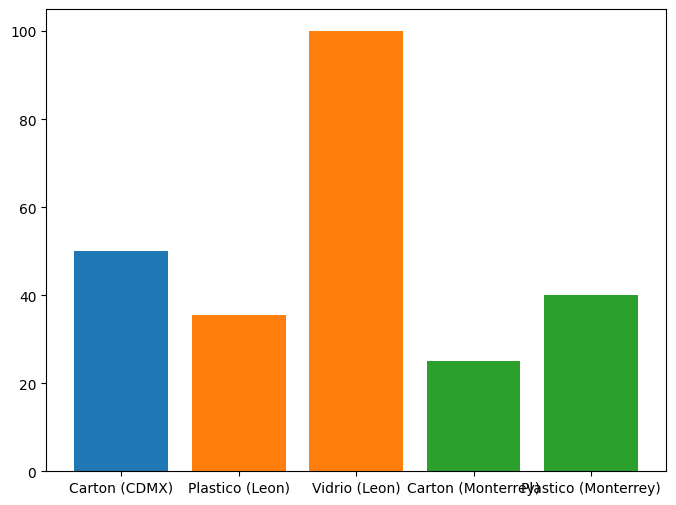

In [ ]:
# 13. Generamos una grafica de barras para visualizar el reciclaje por ciudad y material
plt.figure(figsize=(8, 6)) # Tamano de la grafica
for ciudad in df["ciudad"].unique():
  subset = df[df["ciudad"]==ciudad]
  plt.bar(subset["material"] + " (" + ciudad + ")", subset["total_kg"], label=ciudad)